<a href="https://colab.research.google.com/github/localhost8800/D/blob/main/Copy_of_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1) Create a simple RNN model for generating data using text and predict the
# text using a pre-trained model.(Use ReLU and Softmax activation function).
# (Use shakespeare.txt file)

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding

# Load the dataset
with open("shakespeare.txt", "r", encoding="utf-8") as file:
    text = file.read().lower()

# Use a small portion of the text
text = text[:20000]

# Create character vocabulary
chars = sorted(set(text))
char_to_num = {c: i for i, c in enumerate(chars)}
num_to_char = {i: c for i, c in enumerate(chars)}

# Convert characters into numbers
data = np.array([char_to_num[c] for c in text])

# Prepare input and output sequences
seq_length = 40
X = []
y = []

for i in range(len(data) - seq_length):
    X.append(data[i:i + seq_length])
    y.append(data[i + seq_length])

X = np.array(X)
y = np.array(y)

# Create the RNN model
model = Sequential([
    Embedding(len(chars), 32),
    SimpleRNN(64, activation="relu"),
    Dense(len(chars), activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model summary
model.summary()

# Train the model
model.fit(X, y, epochs=5, batch_size=64)

# Generate text
seed = text[:40]
generated_text = seed

for i in range(200):
    input_seq = np.array(
        [[char_to_num[c] for c in generated_text[-seq_length:]]]
    )

    prediction = model.predict(input_seq, verbose=0)
    next_char = num_to_char[np.argmax(prediction)]

    generated_text += next_char

print("\nGenerated Text:\n")
print(generated_text)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0494 - loss: 3.4556
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0883 - loss: 3.3920
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1018 - loss: 3.2282
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1617 - loss: 3.1226
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1587 - loss: 3.0142

Generated Text:

to be, or not to be, that is the questio                                                                                                                                                                                                        


Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.1485
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0324
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0314
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0272
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0245
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0246
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0244
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0238
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0240
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0231 
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0230 
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0226
Epoch 13/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0225
Epoch 14/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0216
Epoch 15/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0218
Epoch 16/20
10/10 ━

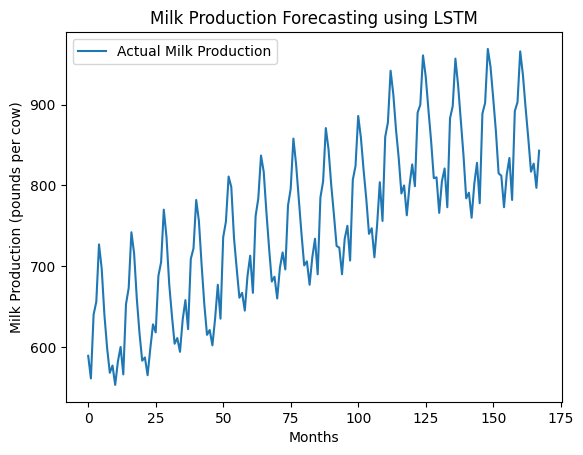

In [ ]:
# 2) Write a python program to implement time series forecasting in Recurrent
# Neural network using LSTM module.( Use monthly_milk_production.csv)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load dataset using URL
url = "https://raw.githubusercontent.com/plotly/datasets/master/monthly-milk-production-pounds.csv"
data = pd.read_csv(url)

# Select milk production column
milk = data.iloc[:, 1].values.reshape(-1, 1)

# Normalize data
scaler = MinMaxScaler()
milk = scaler.fit_transform(milk)

# Prepare data
X = []
y = []

for i in range(12, len(milk)):
    X.append(milk[i-12:i, 0])
    y.append(milk[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

# Create LSTM model
model = Sequential([
    LSTM(50, activation="tanh", input_shape=(12, 1)),
    Dense(1)
])

# Compile model
model.compile(optimizer="adam", loss="mean_squared_error")

# Train model
model.fit(X, y, epochs=20, batch_size=16)

# Predict next month
last_12 = milk[-12:].reshape(1, 12, 1)
prediction = model.predict(last_12, verbose=0)
prediction = scaler.inverse_transform(prediction)

print("Predicted Milk Production:", prediction[0][0])

# Plot graph
plt.plot(scaler.inverse_transform(milk), label="Actual Milk Production")
plt.title("Milk Production Forecasting using LSTM")
plt.xlabel("Months")
plt.ylabel("Milk Production (pounds per cow)")
plt.legend()
plt.show()

Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0026
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 3.0308e-05
Epoch 3/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 2.2313e-05
Epoch 4/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 2.3992e-05
Epoch 5/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 2.1647e-05
Epoch 1/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0015
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 1.1358e-05
Epoch 3/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.1200e-05
Epoch 4/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 1.0712e-05
Epoch 5/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 1.1757e-05
LSTM RMSE: 11.280513168878354
GRU RMSE: 8.017695357040067


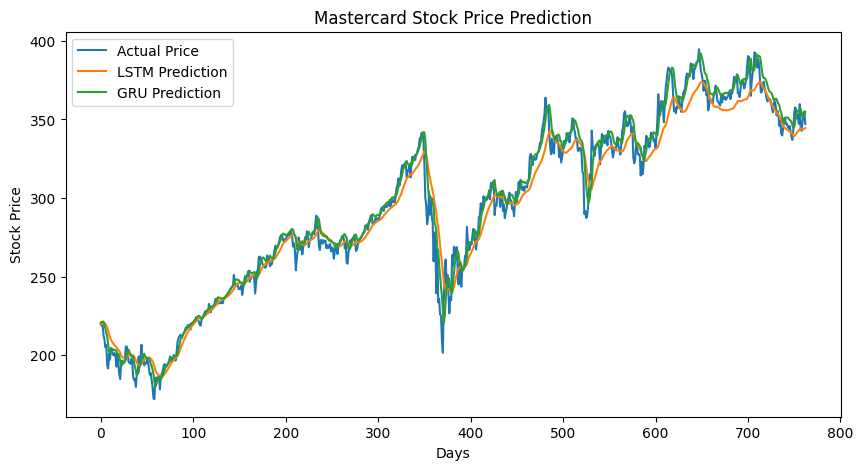

In [ ]:
# 3) Write a python program to predict a stock price from a mastercard stock
# dataset using LSTM and GRU models.


# Assignment 4 - Set A - Q3
# Stock Price Prediction using LSTM and GRU

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

# Load dataset from URL
url = "https://raw.githubusercontent.com/andresca94/MasterCard-Stock-Price-Prediction-Using-LSTM-and-GRU/main/Mastercard_stock_history.csv"
data = pd.read_csv(url)

# Select closing price
prices = data["Close"].values.reshape(-1, 1)

# Normalize data
scaler = MinMaxScaler()
prices = scaler.fit_transform(prices)

# Prepare sequences
X, y = [], []
for i in range(60, len(prices)):
    X.append(prices[i-60:i, 0])
    y.append(prices[i, 0])

X = np.array(X)
y = np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split into training and testing data
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Create LSTM model
lstm_model = Sequential([
    LSTM(50, input_shape=(60, 1)),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mean_squared_error")
lstm_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

# Create GRU model
gru_model = Sequential([
    GRU(50, input_shape=(60, 1)),
    Dense(1)
])

gru_model.compile(optimizer="adam", loss="mean_squared_error")
gru_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

# Predict stock prices
lstm_pred = lstm_model.predict(X_test, verbose=0)
gru_pred = gru_model.predict(X_test, verbose=0)

# Convert predictions to original prices
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate RMSE
print("LSTM RMSE:", np.sqrt(mean_squared_error(actual, lstm_pred)))
print("GRU RMSE:", np.sqrt(mean_squared_error(actual, gru_pred)))

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(actual, label="Actual Price")
plt.plot(lstm_pred, label="LSTM Prediction")
plt.plot(gru_pred, label="GRU Prediction")
plt.title("Mastercard Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [ ]:
# 4) Write a python program to create a sequential model that processes
# sequences of integers, embeds each integer into a 64-dimensional vector, and
# then process the sequence of vectors using a LSTM layer.

# Assignment 4 - Set A - Q4
# Sequential Model using Embedding and LSTM

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM

# Input sequences of integers
X = np.array([
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11, 12, 13, 14, 15]
])

# Create Sequential Model
model = Sequential([
    Embedding(input_dim=100, output_dim=64, input_length=5),
    LSTM(32)
])

# Display model summary
model.summary()

# Process input sequences
output = model.predict(X)

print("\nOutput Shape:", output.shape)
print("\nOutput:")
print(output)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step

Output Shape: (3, 32)

Output:
[[-0.01310877  0.01583212  0.00334674 -0.00989359 -0.01438105 -0.00555644
  -0.01435509  0.0007202  -0.00412689  0.00805873 -0.00293554  0.01240787
   0.02198749  0.00068632 -0.00549788  0.00198304  0.00491622 -0.00288107
   0.00093569 -0.00171976  0.00796414  0.00234076 -0.00067944 -0.00677381
   0.00508176  0.00288261 -0.00386353  0.00615336 -0.01749159 -0.018263
  -0.01085067 -0.00104492]
 [-0.00454124 -0.00370156 -0.00169326  0.00115902  0.01073426 -0.01369018
  -0.00524551 -0.00746517  0.00063764  0.00210548  0.00490654  0.00575947
  -0.00619842  0.00011934 -0.0038503   0.00936849 -0.00047968  0.00501755
   0.00780002  0.00209004 -0.00589618  0.00716029  0.00230567 -0.00512452
   0.00576399 -0.01542406 -0.01802834 -0.00558457  0.00538206 -0.0055299
   0.00940069  0.00162527]
 [-0.00610582 -0.00348019 -0.00915283  0.00084646 -0.00934982 -0.0037266
   0.00651719 -0.00669856  0.00933678  0.00144017 -0.02220713 -0.

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.8085 - loss: 0.4125 - val_accuracy: 0.8696 - val_loss: 0.3061
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9021 - loss: 0.2541 - val_accuracy: 0.8616 - val_loss: 0.3242
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9308 - loss: 0.1880 - val_accuracy: 0.8617 - val_loss: 0.3269
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9463 - loss: 0.1477 - val_accuracy: 0.8624 - val_loss: 0.3687
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9568 - loss: 0.1222 - val_accuracy: 0.8615 - val_loss: 0.4310
Test Accuracy: 0.861519992351532
Test Loss: 0.4309849143028259


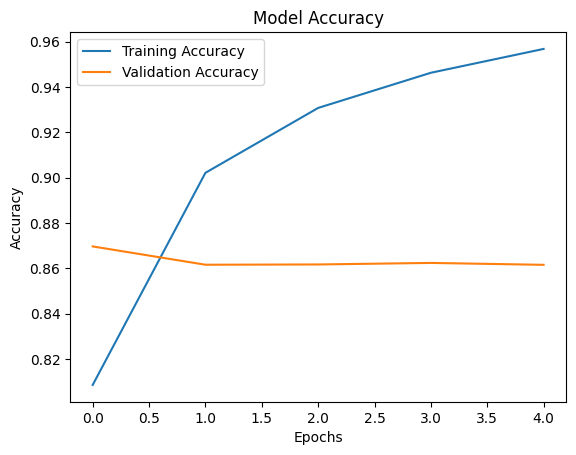

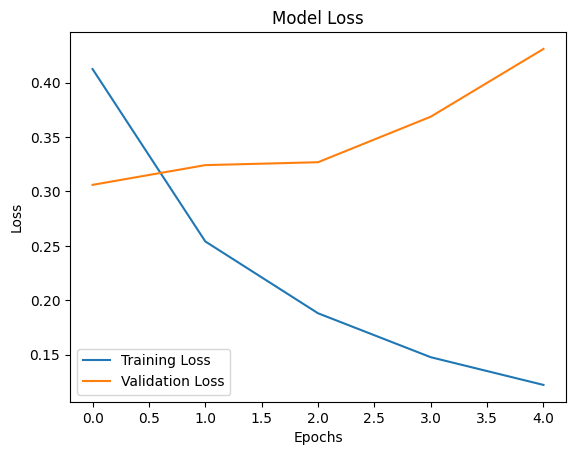

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sentiment: Positive


In [ ]:
# 1) Create a Bi-directional RNN model to perform sentiment analysis and
# predict the sentiment for a given user sentence and also compute the model
# accuracy and model loss with respect to the number of epochs.

# Assignment 5 - Q1
# Bi-directional RNN for Sentiment Analysis

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
vocab_size = 10000
max_length = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

# Create model
model = Sequential([
    Embedding(vocab_size, 64),
    Bidirectional(LSTM(32)),
    Dense(1, activation="sigmoid")
])

# Compile model
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Train model
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

# Plot accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()

# Predict sentiment for user sentence
word_index = imdb.get_word_index()

def predict_sentiment(sentence):
    sequence = [1]
    for word in sentence.lower().split():
        index = word_index.get(word, 2) + 3
        sequence.append(index if index < vocab_size else 2)

    sequence = pad_sequences([sequence], maxlen=max_length)
    prediction = model.predict(sequence, verbose=0)[0][0]

    if prediction >= 0.5:
        print("Sentiment: Positive")
    else:
        print("Sentiment: Negative")

# Test sentence
predict_sentiment("This movie is very good and wonderful")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8836 - loss: 0.3878
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9444 - loss: 0.1946
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9535 - loss: 0.1593
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9604 - loss: 0.1375
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9646 - loss: 0.1220
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9656 - loss: 0.1184
Test Accuracy: 0.9656000137329102
Test Loss: 0.11836332082748413
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
Predicted Digit: 7
Actual Digit: 7


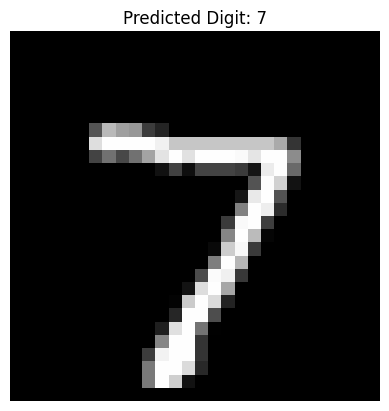

In [ ]:
# 2) Write a python program to recognize handwritten digits using RNN.

# Assignment 5 - Q2
# Handwritten Digit Recognition using RNN

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Create RNN model
model = Sequential([
    SimpleRNN(128, activation="tanh", input_shape=(28, 28)),
    Dense(10, activation="softmax")
])

# Compile model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train model
model.fit(X_train, y_train, epochs=5, batch_size=64)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

# Predict digit
prediction = model.predict(X_test[:1])
digit = prediction.argmax()

print("Predicted Digit:", digit)
print("Actual Digit:", y_test[0])

# Display handwritten digit
plt.imshow(X_test[0], cmap="gray")
plt.title("Predicted Digit: " + str(digit))
plt.axis("off")
plt.show()